In [ ]:
import requests
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

print("All required libraries imported successfully.")

All required libraries imported successfully.


In [ ]:
url = "https://api.github.com/search/repositories?q=machine+learning&sort=stars&order=desc&per_page=100"

response = requests.get(url)

if response.status_code == 200:
    data = response.json()
    raw_df = pd.DataFrame(data['items'])
    print(f"Successfully retrieved {len(raw_df)} repositories from API.")
else:
    print(f"Failed to retrieve data. Status code: {response.status_code}")

Successfully retrieved 100 repositories from API.


In [ ]:
print("Raw Dataset Columns:")
print(raw_df.columns.tolist())

raw_df.info()

keep_cols = [
    'name',
    'full_name',
    'stargazers_count',
    'forks_count',
    'language',
    'created_at',
    'owner',
    'license'
]

df = raw_df[keep_cols].copy()
df.head(3)

Raw Dataset Columns:
['id', 'node_id', 'name', 'full_name', 'private', 'owner', 'html_url', 'description', 'fork', 'url', 'forks_url', 'keys_url', 'collaborators_url', 'teams_url', 'hooks_url', 'issue_events_url', 'events_url', 'assignees_url', 'branches_url', 'tags_url', 'blobs_url', 'git_tags_url', 'git_refs_url', 'trees_url', 'statuses_url', 'languages_url', 'stargazers_url', 'contributors_url', 'subscribers_url', 'subscription_url', 'commits_url', 'git_commits_url', 'comments_url', 'issue_comment_url', 'contents_url', 'compare_url', 'merges_url', 'archive_url', 'downloads_url', 'issues_url', 'pulls_url', 'milestones_url', 'notifications_url', 'labels_url', 'releases_url', 'deployments_url', 'created_at', 'updated_at', 'pushed_at', 'git_url', 'ssh_url', 'clone_url', 'svn_url', 'homepage', 'size', 'stargazers_count', 'watchers_count', 'language', 'has_issues', 'has_projects', 'has_downloads', 'has_wiki', 'has_pages', 'has_discussions', 'forks_count', 'mirror_url', 'archived', 'disabl

,name,full_name,stargazers_count,forks_count,language,created_at,owner,license
0,tensorflow,tensorflow/tensorflow,196990,76044,C++,2015-11-07T01:19:20Z,"{'login': 'tensorflow', 'id': 15658638, 'node_...","{'key': 'apache-2.0', 'name': 'Apache License ..."
1,transformers,huggingface/transformers,164196,34260,Python,2018-10-29T13:56:00Z,"{'login': 'huggingface', 'id': 25720743, 'node...","{'key': 'apache-2.0', 'name': 'Apache License ..."
2,ML-For-Beginners,microsoft/ML-For-Beginners,89461,21956,Jupyter Notebook,2021-03-03T01:34:05Z,"{'login': 'microsoft', 'id': 6154722, 'node_id...","{'key': 'mit', 'name': 'MIT License', 'spdx_id..."


In [ ]:
df['owner_name'] = df['owner'].apply(lambda item: item['login'] if isinstance(item, dict) and 'login' in item else None)

df['license_name'] = df['license'].apply(
    lambda item: item['name'] if isinstance(item, dict) and item is not None and 'name' in item else 'Unknown'
)

df.drop(columns=['owner', 'license'], inplace=True)

df['language'] = df['language'].fillna('Unknown')
df['owner_name'] = df['owner_name'].fillna('Unknown')

before_dup = len(df)
df.drop_duplicates(subset=['full_name'], inplace=True)
print(f"Duplicates removed: {before_dup - len(df)}")

Duplicates removed: 0


In [ ]:
df['created_at'] = pd.to_datetime(df['created_at'])
df['created_year'] = df['created_at'].dt.year

df.rename(columns={
    'stargazers_count': 'stars',
    'forks_count': 'forks'
}, inplace=True)

df.to_csv("github_projects.csv", index=False)
print("Cleaned data successfully saved to 'github_projects.csv'.")

df.head()

Cleaned data successfully saved to 'github_projects.csv'.


,name,full_name,stars,forks,language,created_at,owner_name,license_name,created_year
0,tensorflow,tensorflow/tensorflow,196990,76044,C++,2015-11-07 01:19:20+00:00,tensorflow,Apache License 2.0,2015
1,transformers,huggingface/transformers,164196,34260,Python,2018-10-29 13:56:00+00:00,huggingface,Apache License 2.0,2018
2,ML-For-Beginners,microsoft/ML-For-Beginners,89461,21956,Jupyter Notebook,2021-03-03 01:34:05+00:00,microsoft,MIT License,2021
3,funNLP,fighting41love/funNLP,82514,15265,Python,2018-08-21 11:20:39+00:00,fighting41love,Unknown,2018
4,awesome-machine-learning,josephmisiti/awesome-machine-learning,74044,15608,Python,2014-07-15 19:11:19+00:00,josephmisiti,Other,2014


In [ ]:
conn = sqlite3.connect("github_data.db")

df.to_sql("Repositories", conn, if_exists="replace", index=False)
print("Database 'github_data.db' created and populated.")

Database 'github_data.db' created and populated.


In [ ]:
query_top_stars = """
SELECT name, owner_name, stars, forks, language
FROM Repositories
WHERE stars > 50000
ORDER BY stars DESC
LIMIT 10;
"""

df_top_stars = pd.read_sql_query(query_top_stars, conn)
df_top_stars

,name,owner_name,stars,forks,language
0,tensorflow,tensorflow,196990,76044,C++
1,transformers,huggingface,164196,34260,Python
2,ML-For-Beginners,microsoft,89461,21956,Jupyter Notebook
3,funNLP,fighting41love,82514,15265,Python
4,awesome-machine-learning,josephmisiti,74044,15608,Python
5,scikit-learn,scikit-learn,66963,27291,Python


In [ ]:
query_filtered = """
SELECT name, owner_name, language, stars
FROM Repositories
WHERE (language = 'Python' OR language = 'C++')
  AND NOT owner_name = 'tensorflow'
ORDER BY stars DESC
LIMIT 5;
"""

df_filtered = pd.read_sql_query(query_filtered, conn)
df_filtered

,name,owner_name,language,stars
0,transformers,huggingface,Python,164196
1,funNLP,fighting41love,Python,82514
2,awesome-machine-learning,josephmisiti,Python,74044
3,scikit-learn,scikit-learn,Python,66963
4,gradio,gradio-app,Python,43376


In [ ]:
query_lang_summary = """
SELECT
    language,
    COUNT(*) AS total_repos,
    ROUND(AVG(stars), 2) AS avg_stars,
    SUM(forks) AS total_forks
FROM Repositories
GROUP BY language
HAVING total_repos >= 1
ORDER BY total_repos DESC;
"""

df_lang_summary = pd.read_sql_query(query_lang_summary, conn)
df_lang_summary

,language,total_repos,avg_stars,total_forks
0,Python,30,26547.27,184588
1,Unknown,23,15630.78,65345
2,Jupyter Notebook,19,17064.11,85957
3,C++,12,32173.33,112580
4,JavaScript,3,20596.33,6201
5,Go,3,8968.67,2452
6,HTML,2,11728.00,4618
7,C#,2,14488.50,6431
8,TeX,1,8043.00,1332
9,Scala,1,12518.00,1899


In [ ]:
query_trends = """
SELECT created_year, COUNT(*) AS repos_created
FROM Repositories
GROUP BY created_year
ORDER BY created_year ASC;
"""

df_trends = pd.read_sql_query(query_trends, conn)
df_trends

,created_year,repos_created
0,2009,1
1,2010,2
2,2011,2
3,2013,3
4,2014,6
5,2015,7
6,2016,14
7,2017,17
8,2018,18
9,2019,7


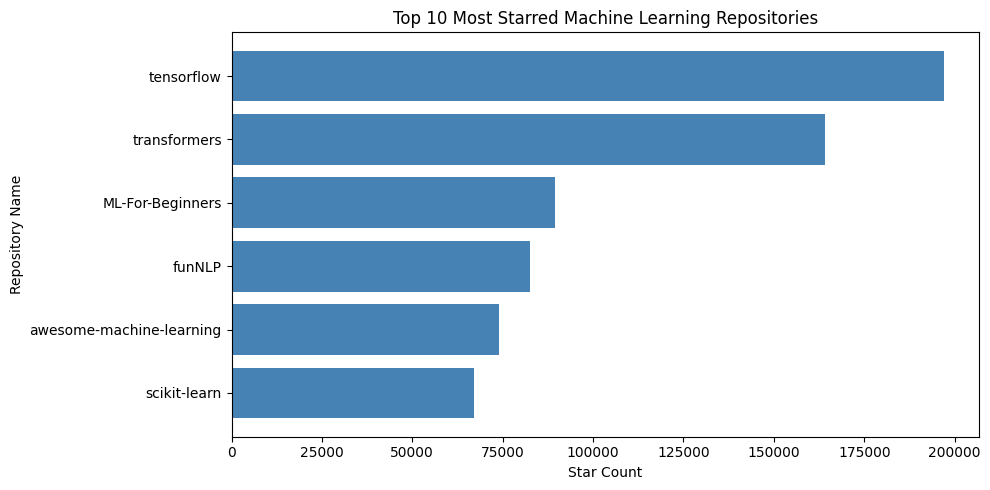

In [ ]:
plt.figure(figsize=(10, 5))
plt.barh(df_top_stars['name'], df_top_stars['stars'], color='steelblue')
plt.xlabel('Star Count')
plt.ylabel('Repository Name')
plt.title('Top 10 Most Starred Machine Learning Repositories')
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig('top_10_repositories.png')
plt.show()

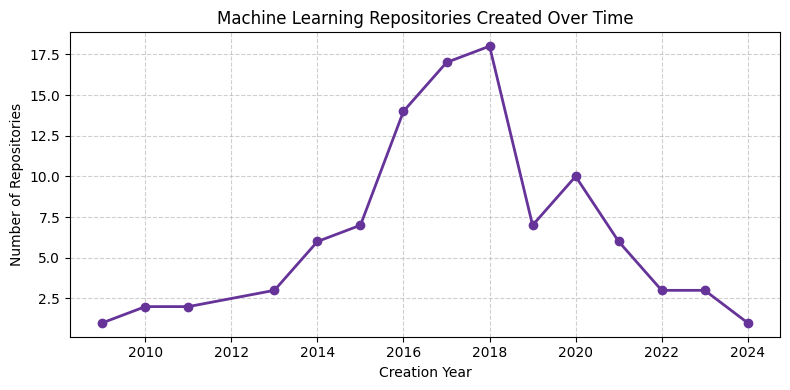

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(df_trends['created_year'], df_trends['repos_created'], marker='o', color='rebeccapurple', linewidth=2)
plt.xlabel('Creation Year')
plt.ylabel('Number of Repositories')
plt.title('Machine Learning Repositories Created Over Time')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.savefig('creation_trend.png')
plt.show()

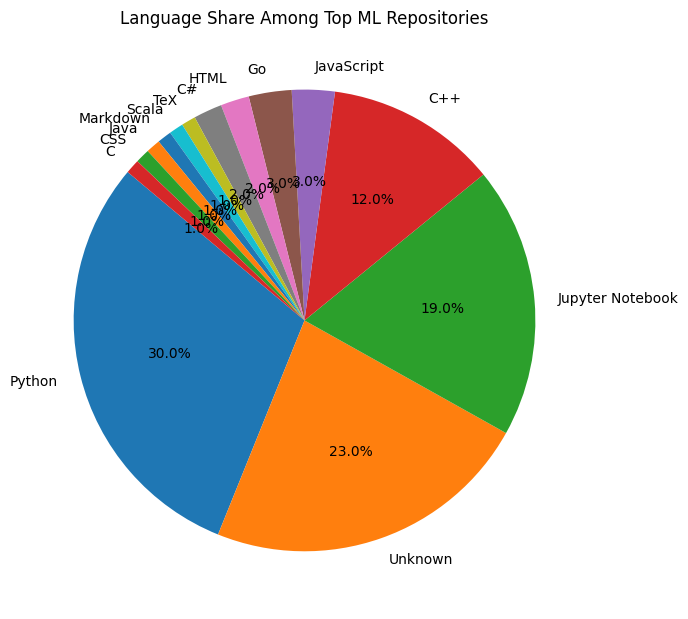

Database connection closed cleanly.


In [ ]:
plt.figure(figsize=(7, 7))
plt.pie(df_lang_summary['total_repos'], labels=df_lang_summary['language'], autopct='%1.1f%%', startangle=140)
plt.title('Language Share Among Top ML Repositories')
plt.tight_layout()

plt.savefig('language_distribution.png')
plt.show()

conn.close()
print("Database connection closed cleanly.")

1. Why is it important to verify data collected from public APIs?
Answer: Verifying public API data ensures the retrieved information is authentic, complete, and accurate. Raw API payloads can contain unexpected null values, network errors, or rate-limit distortions, so verification prevents errors in downstream processing, SQL queries, and visual charts.

2. Why should data analysts document the source of their data?
Answer: Documenting data sources creates transparency, enables auditability, and ensures compliance with API terms of service. It allows evaluators, teammates, and future maintainers to trace information back to its original source and verify the collection methodology.

3. How can missing or inaccurate data affect data analysis and decision-making?
Answer: Missing or inaccurate data distorts statistical metrics, skews SQL aggregation totals, and creates misleading visual trends. Relying on corrupted data leads to flawed business insights, incorrect operational choices, and costly strategic mistakes.

GitHub Repository: https://github.com/unavailableyoussef/SecondTermProject